# CT Power Harvesting: Response to Clamping Force

## Question
How does harvested power respond to clamping force and is the
relationship consistent across specimens and force ranges?


### Background

A current transformer (CT) clamps around a conductor and harvests power from the magnetic field produced by the current flowing through it. The core is made of two halves that close around the conductor and power transfer depends on the magnetic path through those halves being complete which only happens when the faces meet cleanly. Poor contact from insufficient clamping force, core misalignment or debris on the faces introduces an air gap and reduces the power harvested.

This notebook looks at how clamping force affects the power harvested by a nanocrystalline CT. The CT output is passed through a full wave rectifier and smoothing capacitor into a 5 V constant voltage DC load and the current delivered to the load is recorded as force is increased. Power is calculated from that current. 

### Setup

This notebook uses ct_data and ct_plots src/ modules for loading and plotting. 
Analysis logic lives there while narrative is contained in the notebook.

In [9]:
%load_ext autoreload
%autoreload 2

import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append("../src")
from ct_data import load_benchmarks, load_trial
from ct_plots import compare_sweeps, compare_sweeps_grouped, load_all_sweeps


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Data and method

Each trial is recorded as a single CSV in `data/raw/` named `trial_NNN_YYYY-MM-DD.csv`. In these trials clamping force is swept while line current and load voltage are held (once sufficient power is generated) and harvested power is the measured response.

Loading and validation are handled by `load_trial()` in `ct_data.py`: it reads the raw CSV, derives `power_mW` from output current and load voltage and validates the schema before returning. Plotting goes through `ct_plots.py` which applies one house style so every figure is comparable.


## Findings

### Power increases with clamping force (for POC 1.0 units)

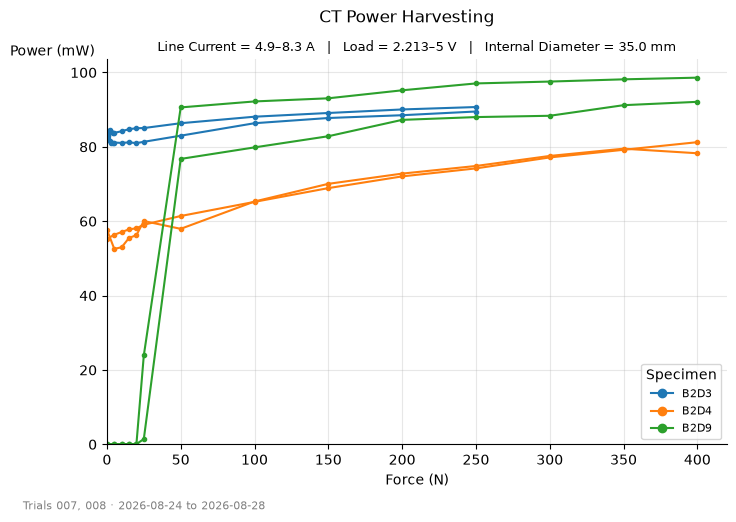

In [10]:
fig, ax = compare_sweeps(["007", "008"])
fig.suptitle("CT Power Harvesting")
fig.savefig("../figures/compare_007_008_full.png", dpi=300, bbox_inches="tight")
plt.show()

### The clamp method used in POC 1.0 field trial did not provide enough clamp force to harvest substaintial power.

The screw clamp design under development (V1 and V2) show signficant improvement in power harvesting under equal conditons.

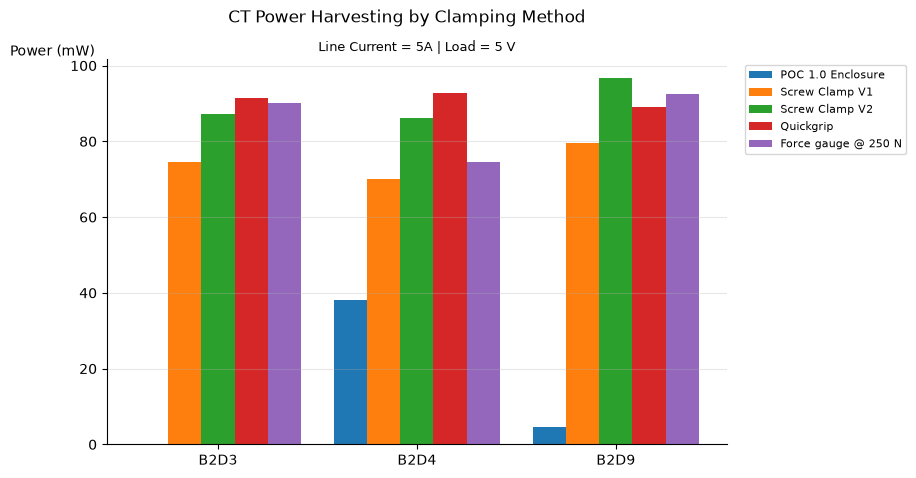

In [11]:
bench = load_benchmarks("001")

# the 5th bar is a groupby-reduction of the sweeps, not a benchmark measurement
sweeps = pd.concat([load_trial("007"), load_trial("008")], ignore_index=True)
at_250 = (
    sweeps.loc[sweeps["force_N"] == 250]
    .groupby("specimen_id", as_index=False)["power_mW"]
    .mean()
)
at_250["clamp_method"] = "Force gauge @ 250 N"

bar_data = pd.concat(
    [bench[["specimen_id", "clamp_method", "power_mW"]], at_250], ignore_index=True
)

# editorial — order lives in the notebook, not the data
cts = ["B2D3", "B2D4", "B2D9"]
method_order = [
    "POC 1.0 Enclosure",
    "Screw Clamp V1",
    "Screw Clamp V2",
    "Quickgrip",
    "Force gauge @ 250 N",
]
pivot = bar_data.pivot(
    index="specimen_id", columns="clamp_method", values="power_mW"
).reindex(index=cts, columns=method_order)

n = len(method_order)
width = 1 / (n + 1)
x = np.arange(len(cts))

fig, ax = plt.subplots(figsize=(8, 5))
for i, method in enumerate(method_order):
    offset = (i - (n - 1) / 2) * width
    ax.bar(x + offset, pivot[method].values, width, label=method)

ax.set_xticks(x)  # ticks land dead-centre now, no fudge factor
ax.set_xticklabels(cts)
ax.set_ylabel("Power (mW)", rotation=0, ha="right", va="center")
ax.yaxis.set_label_coords(-0.02, 1.02)
ax.set_ylim(bottom=0)
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.02, 1))
ax.grid(True, axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title("Line Current = 5A | Load = 5 V", fontsize=9)

fig.suptitle("CT Power Harvesting by Clamping Method")
fig.savefig("../figures/benchmark_bars.png", dpi=300, bbox_inches="tight")
plt.show()

### POC 1.0 units need far more clamp force than POC 2.0 — Contamination and damage is the likely cause

POC 1.0 and 2.0 units differ in two ways: diameter (35 vs 50 mm) and condition (POC 1.0 units are contaminated and damaged from lab and field use, POC 2.0 are in new condition). 

The effect of these differences can't be fully separated with the current specimens. The known effect of an air-gap on power harvesting points to condition as the dominant factor. Contamination and damage directly break the core-face contact that power transfer depends on while a larger diameter theoretically requires higher line current.

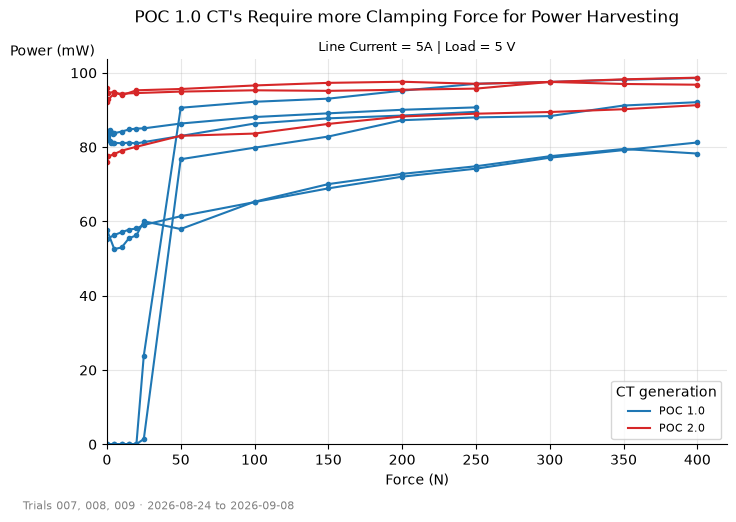

In [12]:
fig, ax = compare_sweeps_grouped(
    ["007", "008", "009"],
    key_col="batch",
    color_map={"POC 1.0": "tab:blue", "POC 2.0": "tab:red"},
    legend_title="CT generation",
)
fig.suptitle("POC 1.0 CT's Require more Clamping Force for Power Harvesting")
ax.set_title("Line Current = 5A | Load = 5 V", fontsize=9)
fig.savefig("../figures/compare_35_50_full.png", dpi=300, bbox_inches="tight")
plt.show()


### POC 2.0 CT's harvest near full power even at low clamp force 

This behaviour is demonstrated consistently at 2A, 5A and 10A of line current.

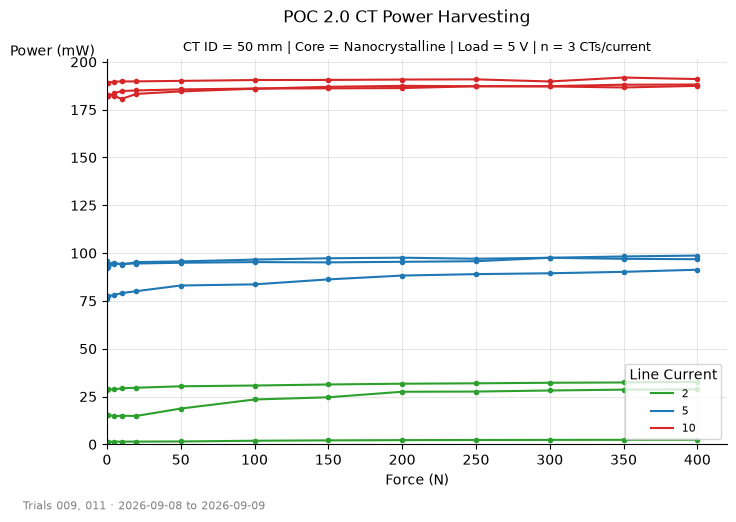

In [13]:
fig, ax = compare_sweeps_grouped(
    ["009", "011"],
    key_col="line_current_A",
    color_map={2: "tab:green", 5: "tab:blue", 10: "tab:red"},
    legend_title="Line Current",
)
fig.suptitle("POC 2.0 CT Power Harvesting")
ax.set_title(
    "CT ID = 50 mm | Core = Nanocrystalline | Load = 5 V | n = 3 CTs/current",
    fontsize=9,
)
fig.savefig("../figures/line_current_2_10_A.png", dpi=300, bbox_inches="tight")
plt.show()

### Next steps

- This testing determined the importance of two key design factors for energy harvesting with split core CT's
  - The CT core surfaces must not be contaminated or damaged
  - If there is damage or debris on the CT core face the core surfaces must be clamped together with signficant force.